# Ethiopia Food Prices — 05 TIME SERIES

Builds a clean monthly time series and studies its structure (trend, seasonality, stationarity) before any
forecasting is attempted in `06 BASELINES` and `07 ARIMA / SARIMA`.

**Series choice.** Rather than working with every market × commodity combination at once, this notebook (and
the two that follow it) focus on one well-covered, representative series: the **national median retail USD
price of white maize** — the single most-reported commodity in the dataset (6,015 retail observations) with
close to continuous monthly coverage since 2006. The same methodology applies to any other market/commodity
series; this one is chosen because it is complete enough to demonstrate the techniques properly, and staple
cereal prices move together strongly nationally (see `03 EDA`, §3.7), so the patterns found here generalize
reasonably well.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)

df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])


## 5.1 Build the series

In [2]:
COMMODITY = 'Maize (white)'
PRICETYPE = 'Retail'

series_raw = (
    df[(df['commodity'] == COMMODITY) & (df['pricetype'] == PRICETYPE) & (df['category'] != 'non-food')]
    .groupby('date')['usdprice']
    .median()
    .sort_index()
)
print(f'{len(series_raw)} monthly observations, {series_raw.index.min().date()} -> {series_raw.index.max().date()}')
series_raw.head()


227 monthly observations, 2006-07-15 -> 2026-07-15


date
2006-07-15    21.490
2006-08-15    19.825
2006-09-15    19.540
2006-10-15    18.390
2006-11-15    19.400
Name: usdprice, dtype: float64

### 5.2 Fill reporting gaps

In [3]:
full_index = pd.date_range(series_raw.index.min(), series_raw.index.max(), freq='MS') + pd.Timedelta(days=14)
missing_months = full_index.difference(series_raw.index)
print(f'{len(missing_months)} missing months out of {len(full_index)} in a fully continuous monthly series:')
print(list(missing_months.strftime('%Y-%m')))


14 missing months out of 240 in a fully continuous monthly series:
['2011-12', '2018-04', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2021-05', '2024-12']


In [4]:
series = series_raw.reindex(full_index).interpolate(method='time')
series.index.name = 'date'
print(f'Series is now continuous: {series.isna().sum()} remaining gaps, {len(series)} months.')


Series is now continuous: 0 remaining gaps, 240 months.


Reporting gaps are filled with **time-weighted linear interpolation** rather than dropped, so the series
stays evenly spaced (a requirement for STL decomposition and for the ARIMA/SARIMA models in the next
notebooks). Most gaps are single isolated months, but one stretch — **September 2018 through June 2019 (9
consecutive months)** — is interpolated across a genuine multi-month reporting hole, not just a one-off
skip. That's a bigger assumption than the other gaps, so the 2018–2019 segment of the series should be read
as lower-confidence than the rest, and it's marked on the chart below so it isn't invisible downstream.


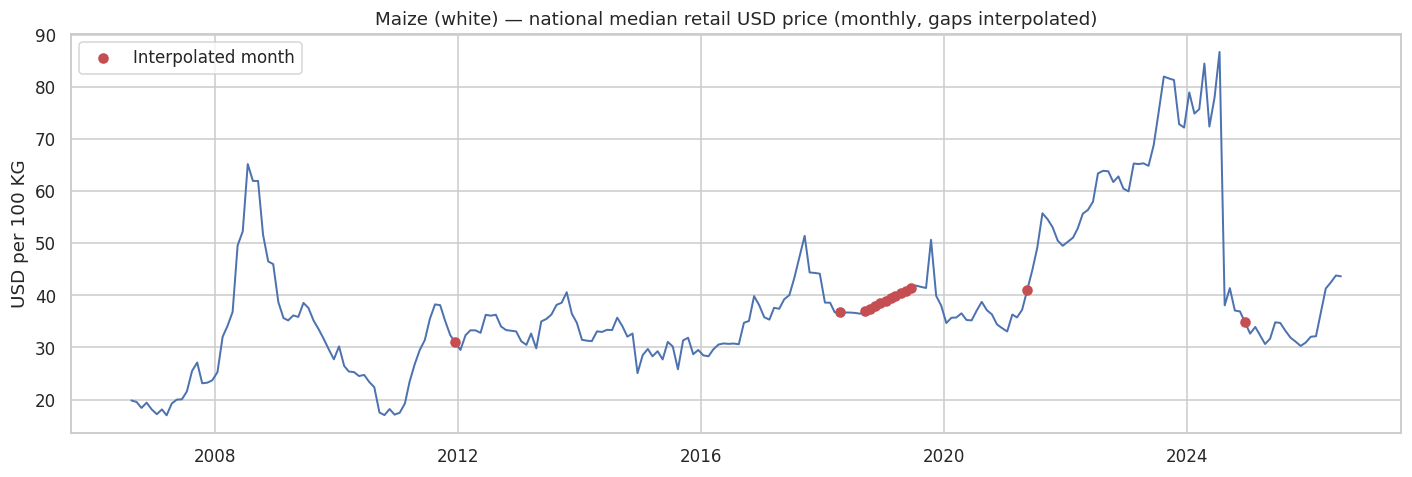

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(series.index, series.values, color='#4C72B0', linewidth=1.3)
ax.scatter(missing_months, series.reindex(missing_months), color='#C44E52', zorder=5, s=35, label='Interpolated month')
ax.set_title(f'{COMMODITY} — national median retail USD price (monthly, gaps interpolated)')
ax.set_ylabel('USD per 100 KG')
ax.legend()
plt.tight_layout()
plt.show()


## 5.3 Trend / seasonal / residual decomposition (STL)

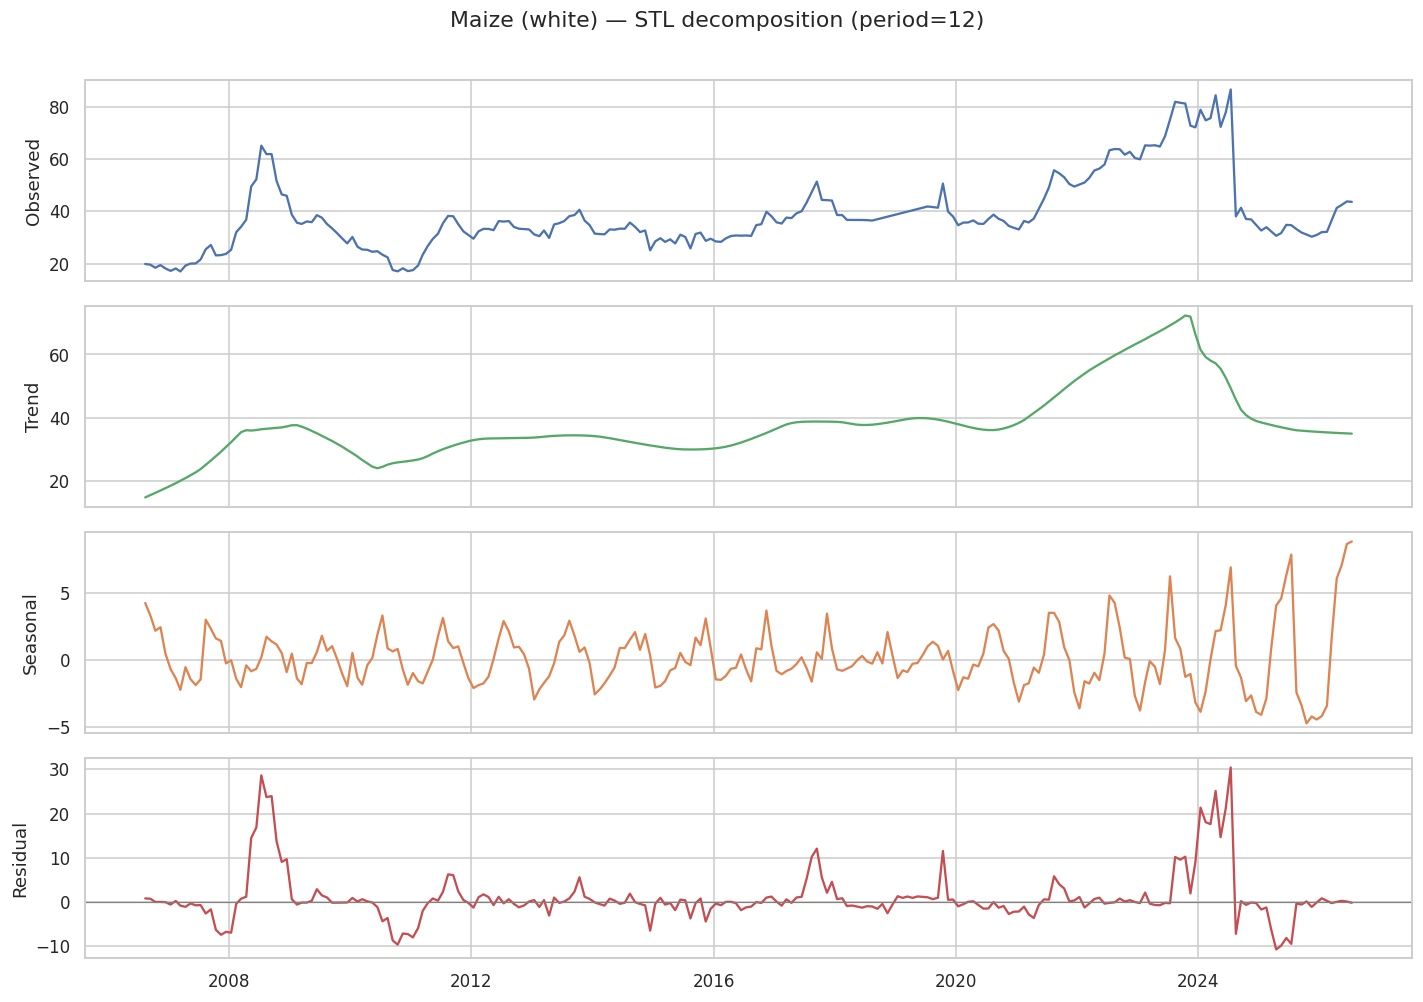

In [6]:
stl = STL(series, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(series.index, series.values, color='#4C72B0'); axes[0].set_ylabel('Observed')
axes[1].plot(series.index, result.trend, color='#55A868'); axes[1].set_ylabel('Trend')
axes[2].plot(series.index, result.seasonal, color='#DD8452'); axes[2].set_ylabel('Seasonal')
axes[3].plot(series.index, result.resid, color='#C44E52'); axes[3].axhline(0, color='gray', lw=0.8)
axes[3].set_ylabel('Residual')
fig.suptitle(f'{COMMODITY} — STL decomposition (period=12)', y=1.01)
plt.tight_layout()
plt.show()


In [7]:
seasonal_strength = 1 - result.resid.var() / (result.seasonal + result.resid).var()
trend_strength = 1 - result.resid.var() / (result.trend + result.resid).var()
print(f'Trend strength    : {trend_strength:.3f}  (0 = no trend contribution, 1 = trend dominates)')
print(f'Seasonal strength  : {seasonal_strength:.3f}  (0 = no seasonal contribution, 1 = seasonality dominates)')


Trend strength    : 0.827  (0 = no trend contribution, 1 = trend dominates)
Seasonal strength  : 0.155  (0 = no seasonal contribution, 1 = seasonality dominates)


The trend component dominates the series — consistent with the multi-year cereal-price climb seen in
`03 EDA`. Seasonal strength is comparatively modest, confirming the EDA note that the pooled month-of-year
chart there was mostly picking up trend, not a strong, stable seasonal cycle. The residual component still
shows visible spikes, which lines up with the events studied in `04 SPIKE ANALYSIS` — those are structural
shocks that a smooth trend + seasonal model can't absorb.


## 5.4 Stationarity

Two complementary tests are used, since they have opposite null hypotheses and agreeing on both is
stronger evidence than either alone:
- **ADF (Augmented Dickey-Fuller)** — null hypothesis: the series has a unit root (is non-stationary).
- **KPSS** — null hypothesis: the series is stationary (opposite direction).


In [8]:
def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s.dropna(), autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
    print(f'--- {label} ---')
    print(f'ADF  : statistic={adf_stat:.3f}, p-value={adf_p:.4f}  -> {"stationary" if adf_p < 0.05 else "NON-stationary"} (ADF view)')
    print(f'KPSS : statistic={kpss_stat:.3f}, p-value={kpss_p:.4f}  -> {"NON-stationary" if kpss_p < 0.05 else "stationary"} (KPSS view)')
    print()

stationarity_report(series, 'Level (raw USD price)')
stationarity_report(series.diff(), 'First difference')
stationarity_report(series.diff().diff(12), 'First difference + seasonal (12-month) difference')


--- Level (raw USD price) ---
ADF  : statistic=-3.082, p-value=0.0280  -> stationary (ADF view)
KPSS : statistic=0.992, p-value=0.0100  -> NON-stationary (KPSS view)

--- First difference ---
ADF  : statistic=-7.279, p-value=0.0000  -> stationary (ADF view)
KPSS : statistic=0.040, p-value=0.1000  -> stationary (KPSS view)

--- First difference + seasonal (12-month) difference ---
ADF  : statistic=-8.633, p-value=0.0000  -> stationary (ADF view)
KPSS : statistic=0.028, p-value=0.1000  -> stationary (KPSS view)



/tmp/ipykernel_131/814025245.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s.dropna(), autolag='AIC')
/tmp/ipykernel_131/814025245.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_131/814025245.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will 

The level series is non-stationary on both tests, as expected from a series with a strong trend. A
first difference substantially improves stationarity; adding a seasonal (12-month) difference on top is
tested as well since SARIMA models can use seasonal differencing directly. These results directly inform the
`d` and `D` orders tried in `07 ARIMA / SARIMA`.


## 5.5 ACF / PACF

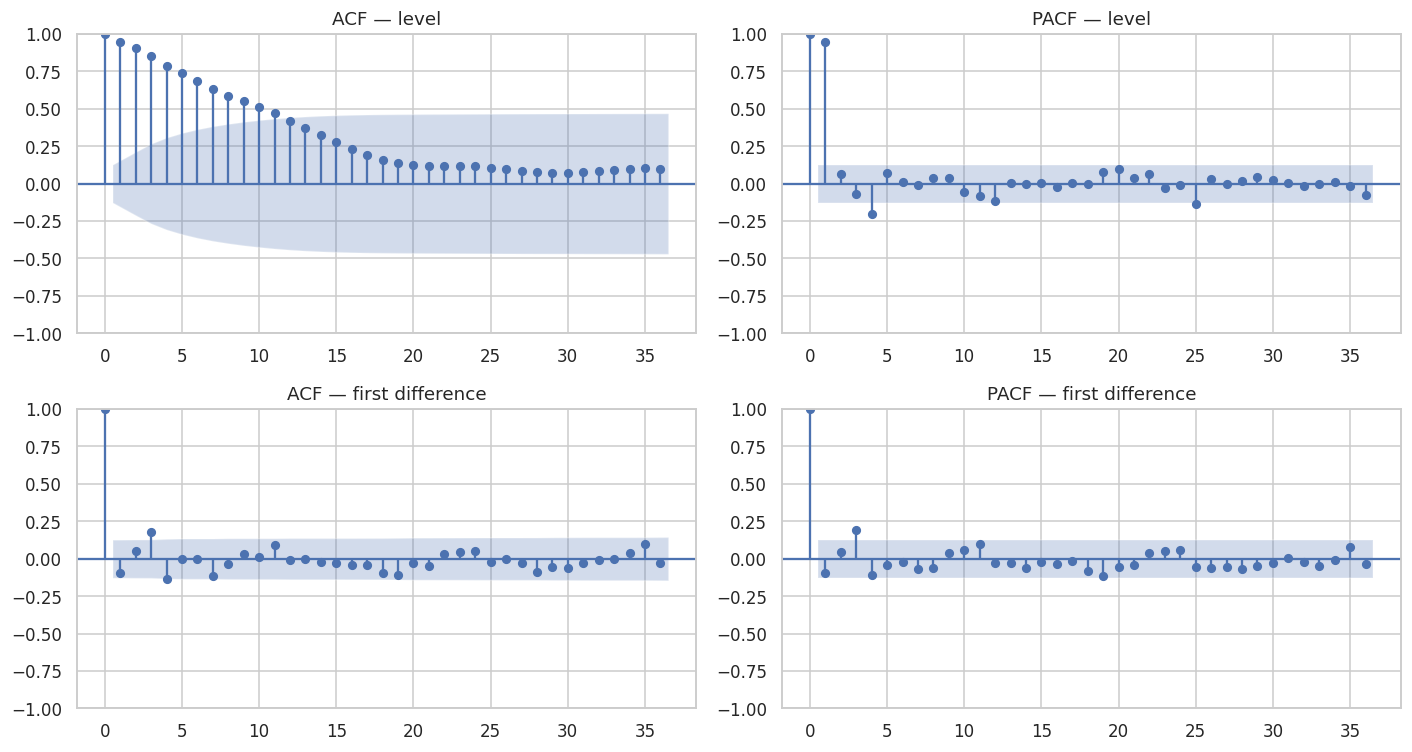

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(series.dropna(), lags=36, ax=axes[0, 0]); axes[0, 0].set_title('ACF — level')
plot_pacf(series.dropna(), lags=36, ax=axes[0, 1], method='ywm'); axes[0, 1].set_title('PACF — level')
plot_acf(series.diff().dropna(), lags=36, ax=axes[1, 0]); axes[1, 0].set_title('ACF — first difference')
plot_pacf(series.diff().dropna(), lags=36, ax=axes[1, 1], method='ywm'); axes[1, 1].set_title('PACF — first difference')
plt.tight_layout()
plt.show()


The level series' ACF decays very slowly — another signature of non-stationarity / a strong trend. After
differencing, autocorrelation drops off much faster, with a visible bump around lag 12 that reinforces the
STL seasonal signal. These plots are a useful visual cross-check on the `(p, d, q)` orders that the grid
search in `07 ARIMA / SARIMA` will search over — they suggest starting from a small number of AR/MA terms
plus first-order (and possibly seasonal) differencing rather than searching a much larger space blindly.


## 5.6 Save the prepared series

In [10]:
out = series.rename('usdprice').to_frame()
out.to_csv('../data/maize_white_retail_national_monthly.csv')
print(f'Saved {len(out)} rows -> ../data/maize_white_retail_national_monthly.csv')
out.tail()


Saved 240 rows -> ../data/maize_white_retail_national_monthly.csv


,usdprice
date,
2026-03-15,36.52
2026-04-15,41.29
2026-05-15,42.45
2026-06-15,43.79
2026-07-15,43.62


---
## Summary

- Built a continuous monthly national series (**Maize (white), retail, USD**), interpolating 14 missing
  months out of 240 (2006–2026) — mostly single months, plus one lower-confidence 9-month stretch
  (Sep 2018 – Jun 2019).
- STL decomposition shows a **trend-dominated** series with a **modest** seasonal component and residual
  spikes that line up with the events found in `04 SPIKE ANALYSIS`.
- The level series is **non-stationary**; a **first difference** is close to stationary, with a **12-month
  seasonal pattern** still visible afterward.
- ACF/PACF support starting an ARIMA/SARIMA search from a small parameter space with `d=1` (and a seasonal
  term worth testing), rather than a large blind grid.
- Output: `../data/maize_white_retail_national_monthly.csv`, used directly by `06 BASELINES` and
  `07 ARIMA / SARIMA`.
